# Project: Antibiotic Resistance of *E. coli* - Explorative Data Analysis (EDA)

Antibiotic resistance, hence the ability of a certain type of bacteria to withstand the treatment with antimicrobial substances (due to e.g. gene mutations) represents a huge problem for modern medicine. Especially if bacteria like *Escherichia coli*, which are common residents of the microbial flora on the human skin and intestines, are able to resist antibiotics (antimicrobial substances), this can lead to non-healing wound infections or other harmful consequences for the host (human). The development of new antibiotics on the other hand is usually not worth investing for the pharmaceutical industry and prommotes the evolution of additional resistance mutations in the bacterial genomes.  
Therefore, I find it important to investigate the currently available antibiotics for their susceptibiliy to hopefully gain new insides to tackle the rising problem of antibiotic resistance in the healthcare system and found a large public dataset for an explorative analysis.

## Outline of this Project
1. **Pre-processing**: Import, clean + standardize (real-world) raw data
2. **Data analysis**: Explorative analysis looking at occurence of antibiotic resistance
3. **Visualization**: Plot results in different graphs to make them more comprehendable
4. **Next Steps**: If possible, apply machine learning model for e.g. most frequent genome locations responsible for resistance mutations.

_________________

Source of dataset: https://www.kaggle.com/datasets/valeriamaciel/e-coli-resistance-dataset/data

### 🧬 *E. coli* Antibiotic Resistance Dataset (Raw from BV-BRC)

This dataset contains 195,000+ raw records of *Escherichia coli* clinical isolates and their antimicrobial susceptibility test results. The data was extracted from the Bacterial and Viral Bioinformatics Resource Center (BV-BRC), a public repository funded by NIAID.

Each entry captures how a specific *E. coli* genome responds to a given antibiotic, along with phenotypic interpretation, lab methods, measurement values (e.g., MIC), and supporting publication links.

### 🔍 What’s Included

- 🧬 Genome ID & strain names
- 💊 Antibiotic tested
- 📏 Measurement (MIC / Zone diameter)
- ✅ Resistance phenotype (Resistant/Susceptible/Intermediate)
- 🧪 Testing method, platform, vendor, and standard (CLSI/EUCAST)
- 🔗 PubMed references and evidence source
_________________
## 1. Data loading & pre-processing

In [2]:
### 1.1. Required Packages & Libraries

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
### 1.2. Loading & Pre-Processing the data set by chunking

### Saving chunkdata to new csv: Perform once to check if chunking works, then comment out to avoid overwriting file in subsequent runs 
# for chunk in pd.read_csv('BVBRC_E.coli_Dataset.csv', chunksize=10000):
#     chunk.to_csv('Dataset_chunk.csv', index=True, mode='a', header=False)  

### Test: Process only the first chunk of data       
# chunk_generator = read_large_file('BVBRC_E.coli_Dataset.csv', 10000)
# df_chunk_raw = next(chunk_generator)        # access the first chunk of data with next()
# print("\nShape of DataFrame:", df_chunk_raw.shape)

columns = pd.read_csv('BVBRC_E.coli_Dataset.csv', nrows=0).columns
print(columns)  # check column names to ensure they match expected names for processing

def read_large_file(file_path, chunk_size):
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        yield chunk

### 1.3. Initialize counters

resistant_counts = Counter()
susceptible_counts = Counter()
intermediate_counts = Counter()
other_rows = []

### 1.4. Process each data_chunk

for data_chunk_raw in read_large_file('BVBRC_E.coli_Dataset.csv', 10000):
    # print("Raw size:", data_chunk_raw.shape)
    data_chunk = data_chunk_raw.dropna(subset=['Resistant Phenotype'])
    # print("\nSize after filtering 'Resistant Phenotype' (drop empty rows):", data_chunk.shape)
    
    # Clean phenotype and antibiotic columns
    data_chunk.loc[:, 'Resistant Phenotype'] = data_chunk['Resistant Phenotype'].str.strip().str.capitalize()
    data_chunk.loc[:, 'Antibiotic'] = data_chunk['Antibiotic'].str.strip().str.title()

    # Filter and count occurrences of each antibiotic in each of the 3 categories:
    resistant = data_chunk[data_chunk['Resistant Phenotype'] == 'Resistant']
    intermediate = data_chunk[data_chunk['Resistant Phenotype'] == 'Intermediate']
    susceptible = data_chunk[data_chunk['Resistant Phenotype'] == 'Susceptible']
    # print("\nResistant:", resistant.shape)      # optional: helps to mediate splitting over chunk iterations
    # print("Susceptible:", susceptible.shape)
    # print("Intermediate:", intermediate.shape)
    
    other_df = data_chunk[~data_chunk['Resistant Phenotype'].isin(['Resistant', 'Susceptible', 'Intermediate'])]
    other_rows.append(other_df)
    
    resistant_counts.update(resistant['Antibiotic'].value_counts().to_dict())
    intermediate_counts.update(intermediate['Antibiotic'].value_counts().to_dict())
    susceptible_counts.update(susceptible['Antibiotic'].value_counts().to_dict())
print("Resistant counts summary:", resistant_counts)  # optional: helps to check if counts are being updated correctly after processing chunks

### 1.5. Combine data chunks into a DataFrame

all_antibiotics = set(resistant_counts) | set(intermediate_counts)  | set(susceptible_counts) 
summary_df = pd.DataFrame(index=sorted(all_antibiotics))
summary_df['Resistant'] = [resistant_counts[ab] for ab in summary_df.index]
summary_df['Intermediate'] = [intermediate_counts[ab] for ab in summary_df.index]
summary_df['Susceptible'] = [susceptible_counts[ab] for ab in summary_df.index]


Index(['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic',
       'Resistant Phenotype', 'Measurement', 'Measurement Sign',
       'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method',
       'Laboratory Typing Method Version', 'Laboratory Typing Platform',
       'Vendor', 'Testing Standard', 'Testing Standard Year',
       'Computational Method', 'Computational Method Version',
       'Computational Method Performance', 'Evidence', 'Source', 'PubMed'],
      dtype='object')
Resistant counts summary: Counter({'Ampicillin': 3899, 'Ciprofloxacin': 1925, 'Amoxicillin/Clavulanic Acid': 1473, 'Trimethoprim/Sulfamethoxazole': 1414, 'Cefotaxime': 1260, 'Amoxicillin': 1059, 'Ceftazidime': 1014, 'Gentamicin': 914, 'Cefuroxime': 756, 'Trimethoprim': 651, 'Tetracycline': 642, 'Ceftriaxone': 582, 'Piperacillin/Tazobactam': 478, 'Cefazolin': 423, 'Cefoxitin': 418, 'Tobramycin': 389, 'Streptomycin': 355, 'Levofloxacin': 337, 'Chloramphenicol': 314, 'Cephalothin': 306, 'Aztreonam': 

## 2. Data Analysis

- At first, we use only the test result categories ('Resistant'|'Intermediate'|'Susceptible') and count them for each antibiotic to get an impression of the results
- The data points, which we cannot include in this analysis, are also worth looking at to identify errors in the process
- Later, we can fine-tune the analysis to focus on certain antibiotic substances that are relevant (most tested, show highest resistance rates etc.) or on certain strains

In [5]:
### 2.1 Metrics for Data Analysis

#### Total summary of dataframes
summary_df['Total'] = summary_df['Resistant'] + summary_df['Intermediate'] + summary_df['Susceptible']
summary_df = summary_df.sort_values(by='Total', ascending=False).drop(columns='Total')

print("\nSummary of Antibiotic analysis:\n", summary_df.head())

#### Output for other rows (not resistant | intermediate | susceptible):
other_df_all = pd.concat(other_rows, ignore_index=True)
print("\nOther Results (unclassified phenotypes):", other_df_all.shape)
print(other_df_all[['Genome ID', 'Antibiotic', 'Resistant Phenotype']])


Summary of Antibiotic analysis:
                Resistant  Intermediate  Susceptible
Gentamicin           914           169         6795
Ciprofloxacin       1925           120         5704
Ceftazidime         1014           250         6218
Ampicillin          3899            13         2894
Cefotaxime          1260            90         5304

Other Results (unclassified phenotypes): (10, 21)
   Genome ID               Antibiotic         Resistant Phenotype
0  562.91162            Sulfisoxazole              Nonsusceptible
1  562.88799            Sulfisoxazole              Nonsusceptible
2  562.88799                Cefazolin              Nonsusceptible
3  562.91162  Piperacillin/Tazobactam              Nonsusceptible
4  562.88799  Piperacillin/Tazobactam              Nonsusceptible
5  562.34086                 Cefepime  Susceptible-dose dependent
6  562.50222                 Cefepime  Susceptible-dose dependent
7  562.91162                Cefazolin              Nonsusceptible
8  562.50

### 2.2. Data Analysis: Results  

- **>50%** of raw data rows get dropped by filtering for empty "Resistant Phenotype" -> inconsistency of documentation in raw data
- only 10 tests had a result outside of resistant | intermediate | susceptible -> 6x "Nonsusceptible", 4x "Susceptible-dose dependent", at first excluded from analysis
- **Most tested antibiotics in dataset | Count of Antimicrobial Susceptibility Test Results**:

  | Antibiotic    | Resistant | Intermediate | Susceptible
  | ------------- | --------- | ------------ | -----------
  | Gentamicin    | 914       | 169          | 6795       
  | Ciprofloxacin | 1925      | 120          | 5704       
  | Ceftazidime   | 1014      | 250          | 6218
  | Ampicillin    | 3899      | 13           | 2894       
  | Cefotaxime    | 1260      | 90           | 5304       

-> **Ampicillin** shows highest number of antibiotic resistance in test results (total count, not normalized)

- Analysis on Measurements (MIC = species-specific minimum inhibitory concentration / Zone diameter) not possible due to lack of data
- Standards of methods are not very high, as many but not all use EUCAST  https://www.eucast.org/
- Differentiation by *E. coli* strain would be interesting to find out, which strain/ genome shows most susceptible or resistant to certain antibiotics

## 3. Data visualization 

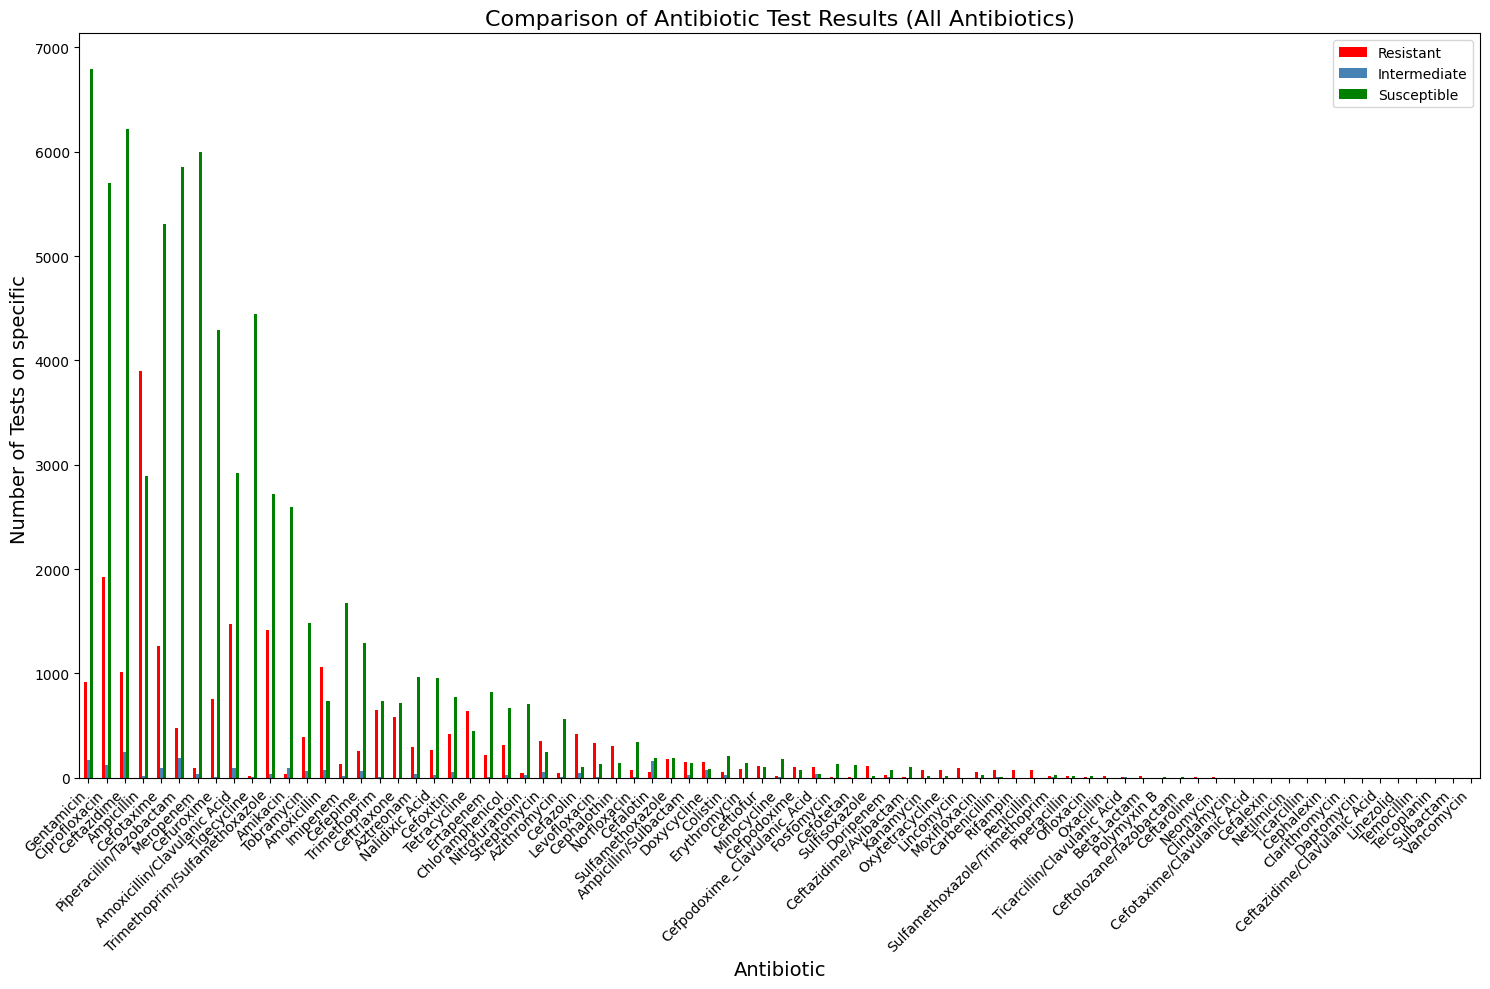

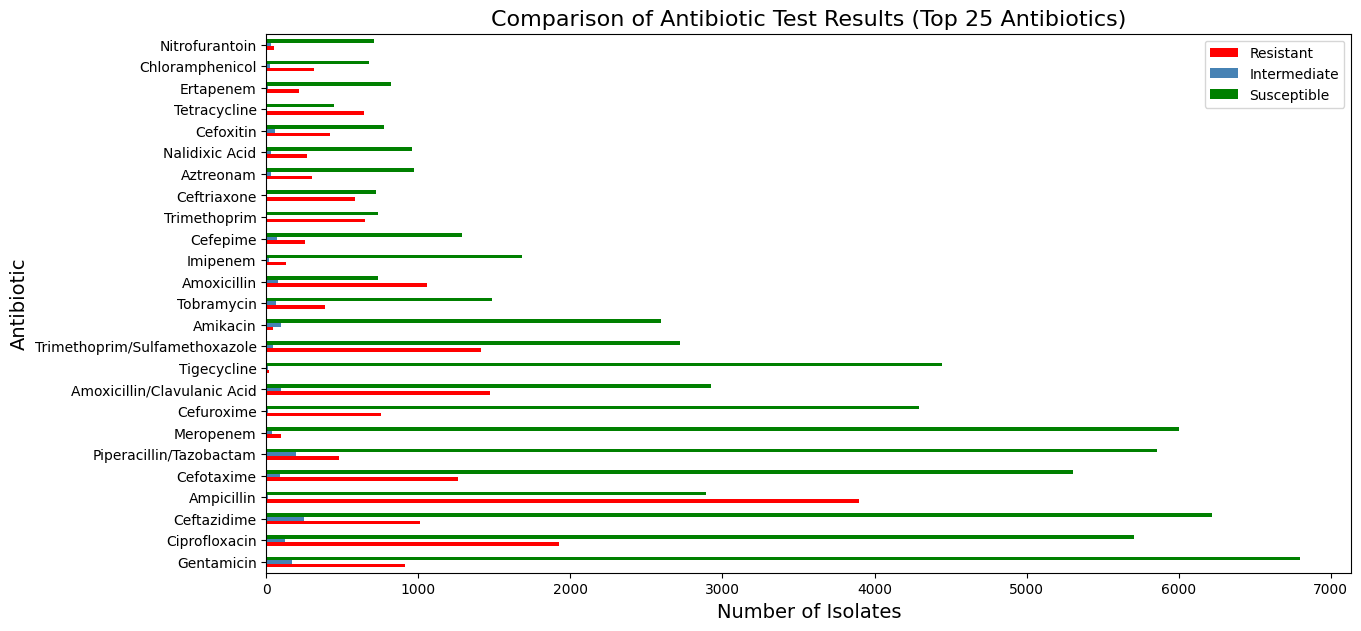

In [6]:
### 3.1 Visualizations for summarized data
summary_df.plot(kind='bar', figsize=(15, 10), color=['red', 'steelblue', 'green'])
plt.title('Comparison of Antibiotic Test Results (All Antibiotics)', fontsize=16)
plt.ylabel('Number of Tests on specific ', fontsize=14)
plt.xlabel('Antibiotic', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

summary_df.head(25).plot(kind='barh', figsize=(14, 7), color=['red', 'steelblue', 'green'])
plt.title('Comparison of Antibiotic Test Results (Top 25 Antibiotics)', fontsize=16)
plt.ylabel('Antibiotic', fontsize=14)
plt.xlabel('Number of Isolates', fontsize=14)
plt.show()

- The high number of different antimicrobial substances tested (total: 77) and the variance in the number of tests within this data set results in a plot, which is hard to read
- -> Improvement: Plot only the top 50 most tested antibiotics and swap the axis for better readability.

### 3.2. Percentage-based stacked bar chart for top 50 most tested antibiotics

Problem: Not all antibiotics have the same number of tests, so we need to normalize the counts to percentages for a fair comparison.   
-> We will calculate the percentage of resistant, intermediate, and susceptible outcomes for the top 50 most frequently tested antibiotics and then plot them as a stacked bar chart.

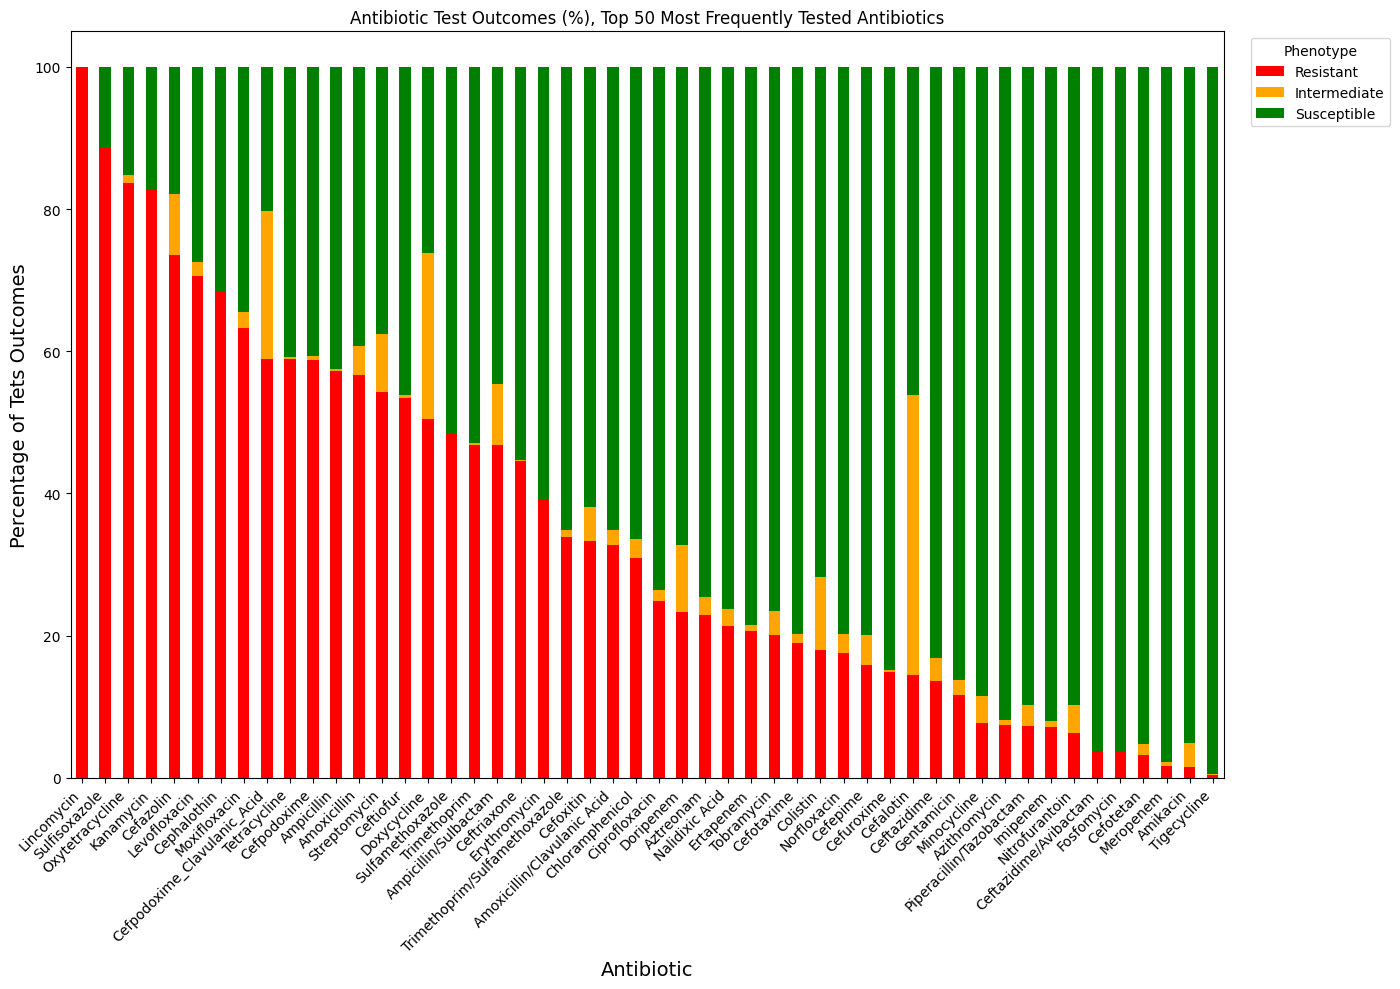

In [ ]:
# 3.2.1. Calculate total test counts per antibiotic
summary_df['Total'] = summary_df.sum(axis=1)

# 3.2.2. Get top 25 most tested antibiotics
top50_by_total = summary_df.sort_values(by='Total', ascending=False).head(50)

# 3.2.3. Normalize counts to % (row-wise)
top50_percent = top50_by_total.drop(columns='Total')
top50_percent_pct = top50_percent.div(top50_percent.sum(axis=1), axis=0) * 100

# 3.2.4. Sort by highest resistance % within top 25
top50_sorted = top50_percent_pct.sort_values(by='Resistant', ascending=False)

# 3.2.5. Plot as stacked bar chart
top50_sorted.plot(kind='bar', stacked=True, figsize=(14, 10), color=['red', 'orange', 'green'])

plt.title('3.2. Antibiotic Test Outcomes (%), Top 50 Most Frequently Tested Antibiotics')
plt.ylabel('Percentage of Tets Outcomes', fontsize=14)
plt.xlabel('Antibiotic', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Phenotype', bbox_to_anchor=(1.15, 1), loc='upper right')
plt.tight_layout()
plt.show()

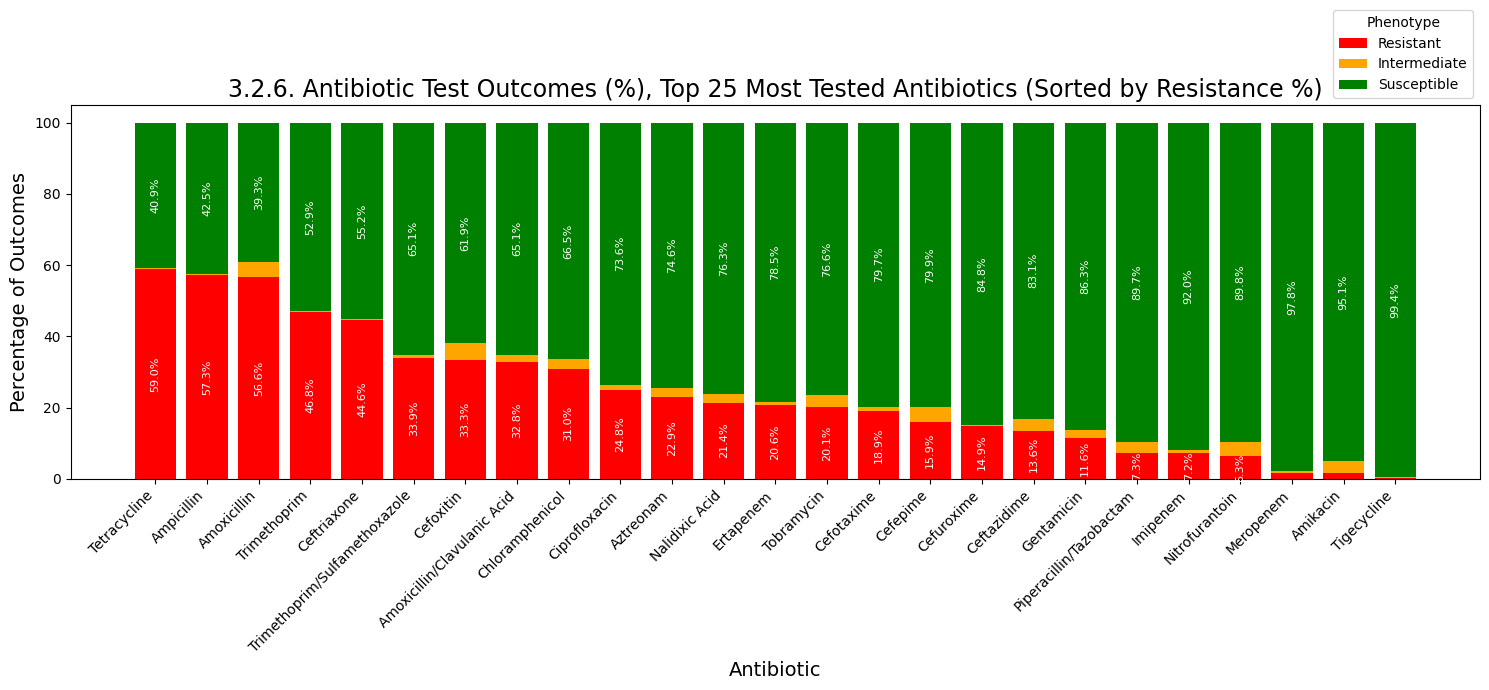

In [14]:
### 3.2.6. Add percentage labels inside the stacked bars for top 25 most tested antibiotics, sorted by resistance % (for better readability)

# summary_df['Total'] = summary_df.sum(axis=1) # run this if the previous cell with total calculation was not executed before

top25_by_total = summary_df.sort_values(by='Total', ascending=False).head(25)
top25_percent = top25_by_total.drop(columns='Total')                            # Normalize
top25_percent_pct = top25_percent.div(top25_percent.sum(axis=1), axis=0) * 100
top25_sorted = top25_percent_pct.sort_values(by='Resistant', ascending=False)   # Sort by highest resistance % within top 25

fig, ax = plt.subplots(figsize=(15, 7))

# Stack bar segments manually to annotate later
bottoms = [0] * len(top25_sorted)
colors = {'Resistant': 'red', 'Intermediate': 'orange', 'Susceptible': 'green'}

for col in ['Resistant', 'Intermediate', 'Susceptible']:
    values = top25_sorted[col]
    bars = ax.bar(top25_sorted.index, values, bottom=bottoms, label=col, color=colors[col])
    
    # Add labels
    for bar, value, bottom in zip(bars, values, bottoms):
        if value > 5:  # avoid clutter for very small bars
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom + value / 2,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                color='white',
                rotation=90
            )
    # Update bottoms for next stack
    bottoms = [b + v for b, v in zip(bottoms, values)]

# Final touches
ax.set_title('3.2.6. Antibiotic Test Outcomes (%), Top 25 Most Tested Antibiotics (Sorted by Resistance %)', fontsize=17)
ax.set_ylabel('Percentage of Outcomes', fontsize=14)
ax.set_xlabel('Antibiotic', fontsize=14)
plt.xticks(rotation=45, ha='right')
ax.legend(title='Phenotype', bbox_to_anchor=(1, 1), loc='lower right')
plt.tight_layout()
plt.show()

### 3.3 Plot of Antibiotics with overall highest Resistance Rates (%)

Besides looking at the most frequently tested antibiotics in the dataset, it is interesting to see which substances overall show the highest rates of resistance in the testes strains of *E. coli* (and might therefore be problematic antibiotics for clinical usage).

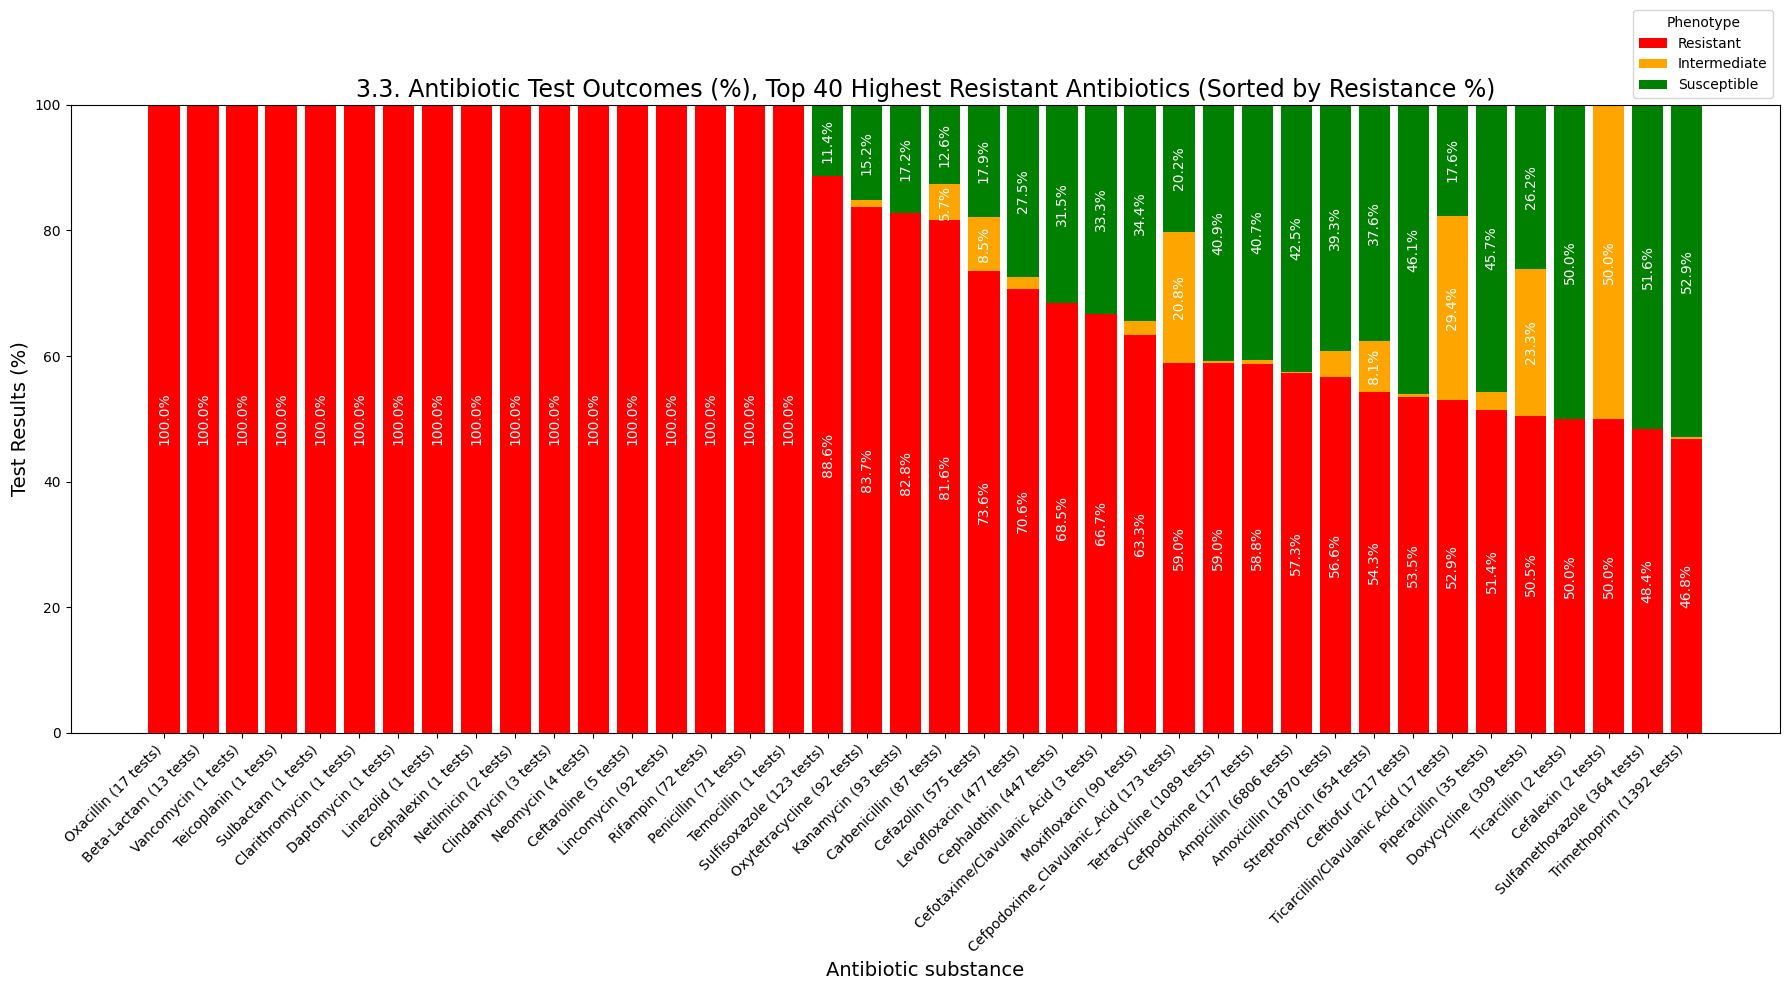

In [13]:
### 3.3.1. Stacked bar plot for top 40 antibiotics with highest resistance % 
# Note: This is an additional plot to visualize the top 40 antibiotics with the highest resistance rates, which may provide more insights into the distribution of resistance across a larger set of antibiotics, while still maintaining readability by focusing on those with the highest resistance percentages (> 50%).

total_normalized = summary_df.drop(columns='Total')
total_norm_rate = total_normalized.div(total_normalized.sum(axis=1), axis=0) * 100  # Normalize and calculate percentages
top40_resist_rate = total_norm_rate.sort_values(by='Resistant', ascending=False).head(40)     # Choose top 40 antibiotics based on highest resistance rates
# print("\nTop 40 Antibiotics with Highest Resistance Rates (%):\n", top40_resist_rate)  # optional: helps to check if the top 40 antibiotics are being selected correctly based on resistance rates

# Include number of tests per antibiotic in the x-axis labels for better context
top40_resist_rate.index = [f"{ab} ({summary_df.loc[ab, 'Total']} tests)" for ab in top40_resist_rate.index]  # add total test counts to x-axis labels for better context

fig, ax = plt.subplots(figsize=(18, 10))

# Stack bar segments manually to annotate later
bottoms = [0] * len(top40_resist_rate)
colors = {'Resistant': 'red', 'Intermediate': 'orange', 'Susceptible': 'green'}

for col in ['Resistant', 'Intermediate', 'Susceptible']:
    values = top40_resist_rate[col]
    bars = ax.bar(top40_resist_rate.index, values, bottom=bottoms, label=col, color=colors[col])
    
    # Add labels
    for bar, value, bottom in zip(bars, values, bottoms):
        if value > 5:  # avoid clutter for very small bars
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom + value / 2,
                f'{value:.1f}%',
                ha='center',
                va='center',
                rotation=90,
                fontsize=10,
                color='white'
            )
    # Update bottoms for next stack
    bottoms = [b + v for b, v in zip(bottoms, values)]

# Plot settings
ax.set_title('3.3. Antibiotic Test Outcomes (%), Top 40 Highest Resistant Antibiotics (Sorted by Resistance %)', fontsize=17)
ax.set_ylabel('Test Results (%)', fontsize=14)
ax.set_xlabel('Antibiotic substance', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.legend(title='Phenotype', bbox_to_anchor=(1, 1), loc='lower right')
plt.tight_layout()
plt.show()

In *Fig. 3.3.* above we gain a different view on the data set as it sets the focus on highest resistance rates:
- **17 antibiotics showed 100% resistance in tests**, but most of them were not tested more than 5 times - the number of tests is relevant for the interpretation
- However, ***Lincomycin*** was tested in 92 data points and still showed 100% resistance, followed by *Rifampicin* and *Penicillin* with >70 tests
- *Ampicillin*, one of the top 5 most tested antibiotics, still shows a high resistance of 57.3% - but only ranks in 29th place when compared with overall highest resistance rates
- -> For the antibiotics with highest resistance rates (despite a larger number of tests), it would be interesting to investigate the common properties and differences further.
- -> Commonly used **Combinations of Antibiotics**, e.g. "Amoxicillin/Clavulanic acid", should be examined in detail and compared for their potential benefit in reducing resistance: 
  - *Amoxicillin* alone (56.6% resistance, Fig. 3.3) vs. Combination of Amoxicillin with Clavulanic acid (32.8%, Fig. 3.2.6), etc.

## 4. Next steps: 
- **Optimize data cleaning**: https://www.kaggle.com/code/valeriamaciel/e-coli-data-cleaning
  - Keeping only relevant columns for analysis
  - Standardizing the values (synonyms of antibiotics + lab methods)
  - drop complete empty and duplicate rows, drop MIC? ("Mic distributions include collated data from multiple sources, geographical areas and time periods and can never be used to infer rates of resistance", https://mic.eucast.org/)
  - check for misspellings in antibiotic labelling 
  - group and compare antibiotic combinations (e.g. with/without Clavulanic acid)
- Exploring **further analysis approaches**, e.g. resistance depending on laboratory method or strain name, for ideas see: https://www.kaggle.com/code/valeriamaciel/e-coli-data-analysis
- Is it possible to map the Genome IDs / locations to antimicrobial susceptibility? 

- For future studies, there is potential to **apply machine learning models** to predict the ideal antibiotic for each strain. However, this would require:
  - Integration of genomic data (currently encoded in the BV-BRC database),
  - Correction of experimental inconsistencies,
  - And the use of data enrichment and annotation strategies to build a more robust dataset.
